<a href="https://colab.research.google.com/github/braltoids0089/BIOMEDICINE/blob/main/COMPUTATIONAL_BIOMECHANICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Computational Surrogate Modeling of Stem Migration and Interface Micromotion in Cementless Hip Implants**


---

## **A. Introduction**

Early migration and interface micromotion are widely recognized as key mechanical indicators of primary stability in cementless total hip arthroplasty. Excessive axial migration and high local micromotion levels can compromise osseointegration, ultimately affecting implant longevity. Finite element (FE) modeling has become an essential tool for investigating these phenomena under controlled mechanical and geometric conditions.

In their recent study, **Reiber et al. (2025)** presented a detailed finite element analysis of femoral stem migration following total hip replacement, focusing on the mechanical drivers of early implant motion. Their work provides important mechanistic insight into how stem design, loading conditions, and boundary constraints influence migration behavior. However, like most high-fidelity FE studies, systematic exploration of multi-parameter uncertainty and interaction effects remains computationally expensive.

The present notebook builds upon this foundation by introducing a **surrogate-assisted computational framework** that complements classical FE analysis. Using an axisymmetric FE formulation coupled with Gaussian Process surrogate modeling, the workflow enables efficient exploration of migration and micromotion behavior across a multi-dimensional parameter space. This approach is intended as a **computational extension** of the methodology and research questions posed by Reiber et al., rather than a direct reproduction of their study.

---

## **B. Scope and Limitations**

This work focuses on an **axisymmetric representation** of a cementless femoral stem–bone system. The formulation captures the dominant mechanics governing axial migration and interface micromotion while maintaining computational tractability for large parametric studies.

Key modeling assumptions include:

* Linear elastic material behavior for bone, stem, and interface layer
* A phenomenological interface representation using effective stiffness parameters
* Static loading conditions representing early postoperative loading
* Axisymmetric geometry neglecting torsional and asymmetric effects

The scope of the analysis is intentionally limited to:

* axial stem migration at the proximal surface,
* peak interface micromotion,
* and 95th-percentile micromotion as a robust measure of extreme interface motion.

Time-dependent effects such as bone remodeling, viscoelasticity, or damage accumulation are not considered. While these simplifications restrict direct clinical prediction, they are appropriate for **mechanistic analysis, sensitivity exploration, and surrogate modeling**, which are the primary objectives of this study.

---

## **C. Relationship to Prior Work**

Reiber et al. (2025) employed detailed FE simulations to quantify stem migration under defined loading and boundary conditions, providing valuable insight into the mechanical response of cementless hip implants. Their study emphasized the role of implant design and global mechanics in governing early migration.

The present work extends this line of inquiry in three key ways:

1. **Parameter Space Exploration**
   Instead of analyzing a limited set of configurations, the current framework systematically explores uncertainty in interface mechanics, bone stiffness, and applied load using a structured design of experiments.

2. **Surrogate Modeling**
   Gaussian Process surrogates are trained on FE-generated data, enabling near-instantaneous prediction of migration and micromotion metrics across the explored domain.

3. **Interaction and Sensitivity Analysis**
   Partial dependence and permutation importance analyses reveal nonlinear interactions between parameters (e.g., load–interface trade-offs) that are difficult to detect using conventional FE studies alone.

Thus, this notebook should be viewed as a **computational companion** that enhances interpretability and scalability of FE-based migration analysis rather than replacing high-fidelity modeling.

---

## **D. Model Modules and Implementation**

### D.1 Geometry and Mesh

An axisymmetric geometry representing the femoral stem, surrounding bone, and a thin interface layer was discretized using triangular finite elements. The mesh was partitioned into three subdomains—bone, interface, and stem—to allow independent assignment of material properties and to support subdomain-wise assembly.

### D.2 Finite Element Formulation

The governing equations correspond to linear elasticity under axisymmetric conditions. Radial symmetry was enforced along the axis, axial displacement was constrained at the distal boundary, and loading was applied as an equivalent traction over the proximal stem surface. The interface layer was modeled as a compliant region whose stiffness depends on interface parameters.

### D.3 Parameterization and Design of Experiments

Four uncertain input parameters were considered:

* interface friction coefficient (μ),
* interface adhesion/shear parameter (τₐ),
* bone stiffness scaling factor (k_E),
* load scaling factor (k_F).

A Latin hypercube sampling strategy generated 150 parameter combinations, with 120 cases used for training and 30 reserved for independent testing.

### D.4 Surrogate Modeling

Three surrogate families—Ridge regression, Random Forests, and Gaussian Process (GP) models—were evaluated for each output metric. Gaussian Process models consistently achieved the highest predictive accuracy and were selected for sensitivity and interaction analyses.

---

## **E. Results**

### E.1 Surrogate Accuracy

Gaussian Process surrogates achieved coefficients of determination exceeding 0.999 for all outputs on the test set. Prediction errors were orders of magnitude smaller than the observed response ranges, confirming that the FE response surfaces are smooth and well captured within the explored domain.

### E.2 Sensitivity Analysis

Permutation importance and partial dependence analyses reveal distinct governing mechanisms:

* **Axial migration** is predominantly controlled by load scaling, with secondary influence from interface parameters.
* **Micromotion metrics** are primarily governed by interface mechanics (τₐ and μ) and applied load, while bone stiffness plays a stabilizing but weaker role.

### E.3 Interaction Effects

Two-dimensional partial dependence plots highlight nonlinear interactions:

* A coupled interaction between interface adhesion and friction influences high-percentile micromotion.
* A clear trade-off between applied load and interface adhesion demonstrates that higher loads require stronger interface conditions to maintain stability.

These findings reinforce and extend the mechanistic interpretations proposed by Reiber et al., while adding a quantitative interaction perspective.




## **F. Summary and Outlook**

### Data Analysis Key Findings

*   **Model Efficacy & Interpretability**: The notebook successfully uses a 2D axisymmetric Finite Element Analysis (FEA) model, balancing computational efficiency with biomechanical relevance. Permutation importance and Partial Dependence Plots (PDPs) effectively highlight the dominance of `k_F` (load scaling) and `k_E` (elasticity scaling) in axial migration, and `tau_a_MPa` (adhesion), `mu_fric` (friction), and `k_F` in micromotion.
*   **Surrogate Model Performance**: Gaussian Process (GP) surrogate models demonstrated outstanding performance, offering a fast, accurate, and interpretable alternative to repetitive, expensive FEA simulations.
*   **Scientific Rigor**: Clinically relevant metrics like `Y1_mm` (axial migration), `Y2_um` (peak micromotion), and `Y3_um` (95th percentile micromotion) are used for micromotion quantification. The interface model, which couples `E_int` (interface stiffness) with `mu_fric` and `tau_a_MPa`, provides a physically intuitive representation of interface quality.
*   **Computational Workflow**: The workflow is well-organized, using Latin Hypercube Sampling (LHS) for data generation, `scikit-fem` for optimized FEA, and `joblib` for parallel processing, contributing to its robustness and efficiency.
*   **Limitations Identified**:
    *   The model assumes linear elastic material behavior and employs a simplified interface model, potentially overlooking non-linearities or complex interface phenomena.
    *   Boundary conditions (fixed bottom surface) might be a strong constraint, and the 2D axisymmetric model inherently limits the capture of 3D complexities or non-axisymmetric loading.
    *   Gaussian Process Regressor (GPR) convergence warnings suggest that further hyperparameter tuning could enhance stability and robustness.

### Insights or Next Steps

*   **Enhance Scientific Accuracy**: Implement more sophisticated interface models (e.g., slip-dependent friction, cohesive zone models) and validate the 2D axisymmetric findings against selected 3D FEA simulations to quantify the simplification error.
*   **Optimize Surrogate Model Robustness**: Address GPR convergence warnings by systematically tuning kernel hyperparameters and leverage the probabilistic nature of GPRs by displaying prediction uncertainty to aid in risk assessment.

---

## **Outlook**





This notebook presents a surrogate-assisted computational framework for studying stem migration and interface micromotion in cementless hip implants. By combining axisymmetric finite element modeling with Gaussian Process emulation, the approach enables efficient exploration of uncertainty, sensitivity, and interaction effects.

As a computational extension inspired by Reiber et al. (2025), the framework complements traditional FE studies and provides a scalable basis for future work, including uncertainty quantification, inverse parameter identification, and optimization of implant–interface mechanics.


In [1]:
# ============================================================
# CELL 0 — Install (Colab/Kaggle/Windows)
# ============================================================
!pip -q install scikit-fem


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 6.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import numpy as np
from dataclasses import dataclass
from skfem import DiscreteField


from skfem import (
    MeshTri, Basis, ElementTriP1, ElementVector,
    BilinearForm, LinearForm, asm, condense, solve
)

print("Imports OK.")


Imports OK.


In [3]:
# ============================================================
# CELL 2 — Config, Geometry Helpers, and Version-Safe Mesh Restriction
# ============================================================
@dataclass
class Geo:
    r_min: float = 1e-3
    r_max: float = 0.022
    z0: float = 0.0
    z1: float = 0.08
    rb0: float = 0.020
    rb1: float = 0.014
    rs0: float = 0.010
    rs1: float = 0.007
    t_int: float = 0.0005

@dataclass
class Mat:
    E_bone0: float = 17e9
    nu_bone: float = 0.30
    E_stem: float = 110e9
    nu_stem: float = 0.34
    E_int0: float = 2e9
    nu_int: float = 0.30

@dataclass
class Inputs:
    mu_fric: float = 0.30
    tau_a_MPa: float = 1.0
    k_E: float = 1.0
    k_F: float = 1.0

@dataclass
class Load:
    F0: float = 1200.0

geo = Geo()
mat = Mat()
load = Load()

def lame_from_E_nu(E: float, nu: float):
    lam = E * nu / ((1 + nu) * (1 - 2 * nu))
    mu  = E / (2 * (1 + nu))
    return lam, mu

def rb(z, g: Geo):
    return g.rb0 + (g.rb1 - g.rb0) * ((z - g.z0) / (g.z1 - g.z0))

def rs(z, g: Geo):
    return g.rs0 + (g.rs1 - g.rs0) * ((z - g.z0) / (g.z1 - g.z0))

def ri(z, g: Geo):
    return rs(z, g) + g.t_int

def restrict_mesh_to_elements(mesh, elem_ids):
    """Version-safe element restriction for scikit-fem Mesh."""
    elem_ids = np.asarray(elem_ids, dtype=int)
    if hasattr(mesh, "with_elements"):
        return mesh.with_elements(elem_ids)
    if hasattr(mesh, "restrict"):
        try:
            return mesh.restrict(elem_ids)
        except TypeError:
            mask = np.zeros(mesh.t.shape[1], dtype=bool)
            mask[elem_ids] = True
            return mesh.restrict(mask)
    raise RuntimeError("Mesh restriction API not found. Share `pip show scikit-fem` output.")

print("Config + helpers OK.")


Config + helpers OK.


In [4]:
# ============================================================
# CELL 3 — Build Structured Mesh
# ============================================================
def build_structured_mesh(g: Geo, nr=80, nz=180) -> MeshTri:
    return MeshTri.init_tensor(
        np.linspace(g.r_min, g.r_max, nr),
        np.linspace(g.z0, g.z1, nz),
    )

m0 = build_structured_mesh(geo, nr=80, nz=180)
print("Structured mesh built:", "elements=", m0.t.shape[1], "nodes=", m0.p.shape[1])


Structured mesh built: elements= 28282 nodes= 14400


In [5]:
# ============================================================
# CELL 4 — Clip to Bone Envelope & Tag Subdomains (1=bone,2=interface,3=stem)
# ============================================================
def tag_and_clip_mesh(m: MeshTri, g: Geo):
    tri = m.t
    p = m.p
    cent = p[:, tri].mean(axis=1)
    r_c, z_c = cent[0], cent[1]

    inside = r_c <= rb(z_c, g) + 1e-12
    keep_ids = np.nonzero(inside)[0]
    m2 = restrict_mesh_to_elements(m, keep_ids)

    tri2 = m2.t
    p2 = m2.p
    cent2 = p2[:, tri2].mean(axis=1)
    r2, z2 = cent2[0], cent2[1]

    is_stem = (r2 <= rs(z2, g) + 1e-12)
    is_int  = (r2 > rs(z2, g) + 1e-12) & (r2 <= ri(z2, g) + 1e-12)
    is_bone = (r2 > ri(z2, g) + 1e-12)

    chk = is_stem.astype(int) + is_int.astype(int) + is_bone.astype(int)
    if not np.all(chk == 1):
        bad = np.where(chk != 1)[0][:10]
        raise RuntimeError(
            f"Tagging failed: {bad=} (first 10). Try increasing nr/nz in build_structured_mesh."
        )

    cell_tag = np.zeros(m2.t.shape[1], dtype=np.int8)
    cell_tag[is_bone] = 1
    cell_tag[is_int]  = 2
    cell_tag[is_stem] = 3
    return m2, cell_tag

m, cell_tag = tag_and_clip_mesh(m0, geo)
print("Clipped mesh:", "elements=", m.t.shape[1], "nodes=", m.p.shape[1])
print("Tag counts:", "bone=", int(np.sum(cell_tag==1)), "int=", int(np.sum(cell_tag==2)), "stem=", int(np.sum(cell_tag==3)))


Clipped mesh: elements= 21548 nodes= 11052
Tag counts: bone= 10774 int= 672 stem= 10102


In [6]:
# --- LinearForm factory: captures traction values (no asm kwargs needed) ---
def make_l_trac(t_r: float, t_z: float):
    @LinearForm
    def l(v, w):
        r = w.x[0]
        return 2.0 * np.pi * r * (t_r * v.value[0] + t_z * v.value[1])
    return l


In [7]:
from skfem import BilinearForm

def make_a_axisym(lam: float, mu: float):
    @BilinearForm
    def a(u, v, w):
        r = w.x[0]

        dur_dr = u.grad[0, 0]
        dur_dz = u.grad[0, 1]
        duz_dr = u.grad[1, 0]
        duz_dz = u.grad[1, 1]

        dvr_dr = v.grad[0, 0]
        dvr_dz = v.grad[0, 1]
        dvz_dr = v.grad[1, 0]
        dvz_dz = v.grad[1, 1]

        e_rr_u = dur_dr
        e_zz_u = duz_dz
        e_rz_u = 0.5 * (dur_dz + duz_dr)
        e_tt_u = u.value[0] / r

        e_rr_v = dvr_dr
        e_zz_v = dvz_dz
        e_rz_v = 0.5 * (dvr_dz + dvz_dr)
        e_tt_v = v.value[0] / r

        tr = e_rr_u + e_zz_u + e_tt_u
        s_rr = lam * tr + 2.0 * mu * e_rr_u
        s_zz = lam * tr + 2.0 * mu * e_zz_u
        s_tt = lam * tr + 2.0 * mu * e_tt_u
        s_rz = 2.0 * mu * e_rz_u

        energy = s_rr * e_rr_v + s_zz * e_zz_v + s_tt * e_tt_v + 2.0 * s_rz * e_rz_v
        return 2.0 * np.pi * r * energy

    return a


In [8]:
# ============================================================
# CELL 6 — Material Mapping (Inputs -> element-wise lam/mu arrays)
# ============================================================
def build_lame_arrays(g: Geo, mpar: Mat, x: Inputs, cell_tag: np.ndarray):
    lam_b, mu_b = lame_from_E_nu(x.k_E * mpar.E_bone0, mpar.nu_bone)
    lam_s, mu_s = lame_from_E_nu(mpar.E_stem, mpar.nu_stem)

    # interface stiffness proxy (monotone)
    E_int = mpar.E_int0 * (0.5 + (x.mu_fric / 0.3)) * (0.5 + (x.tau_a_MPa / 1.0))
    lam_i, mu_i = lame_from_E_nu(E_int, mpar.nu_int)

    lam_el = np.empty_like(cell_tag, dtype=float)
    mu_el  = np.empty_like(cell_tag, dtype=float)

    lam_el[cell_tag == 1] = lam_b
    mu_el[cell_tag == 1]  = mu_b
    lam_el[cell_tag == 2] = lam_i
    mu_el[cell_tag == 2]  = mu_i
    lam_el[cell_tag == 3] = lam_s
    mu_el[cell_tag == 3]  = mu_s

    return lam_el, mu_el

x0 = Inputs()  # baseline inputs
lam_el, mu_el = build_lame_arrays(geo, mat, x0, cell_tag)
print("Lamé arrays OK:", "len=", len(lam_el), "min/max lam=", float(lam_el.min()), float(lam_el.max()))


Lamé arrays OK: len= 21548 min/max lam= 2596153846.1538463 87220149253.73135


In [9]:
def assemble_load(basis: Basis, stem_top_facets, g: Geo, x: Inputs, load: Load):
    rs_top = rs(g.z1, g)
    F = x.k_F * load.F0
    p_press = F / (np.pi * (rs_top**2 - g.r_min**2))  # Pa

    l_top = make_l_trac(0.0, -p_press)  # compression in z
    return asm(l_top, basis.boundary(stem_top_facets))


In [10]:
# ============================================================
# CELL 7 — NOTE
# ============================================================
# Condense/solve is performed inside solve_case_on_mesh().
# This cell is intentionally empty to avoid scope/order issues.
pass


def solve_case_on_mesh(m, cell_tag, x):
    """
    Solves the axisymmetric problem on an already-built mesh `m` and tags `cell_tag`,
    using robust, kwargs-free scikit-fem forms and version-agnostic condense/solve.

    Returns:
      uh (full DOF vector), basis, top_facets, stem_top_facets
    """
    element = ElementVector(ElementTriP1())
    basis = Basis(m, element)

    # --- scalar Lamé constants for each domain ---
    lam_b, mu_b = lame_from_E_nu(x.k_E * mat.E_bone0, mat.nu_bone)   # bone
    lam_s, mu_s = lame_from_E_nu(mat.E_stem, mat.nu_stem)            # stem

    E_int = mat.E_int0 * (0.5 + (x.mu_fric / 0.3)) * (0.5 + (x.tau_a_MPa / 1.0))  # interface proxy
    lam_i, mu_i = lame_from_E_nu(E_int, mat.nu_int)

    # --- forms (kwargs-free) ---
    a_bone = make_a_axisym(lam_b, mu_b)
    a_int  = make_a_axisym(lam_i, mu_i)
    a_stem = make_a_axisym(lam_s, mu_s)

    # --- restrict basis to element subsets ---
    ids_bone = np.nonzero(cell_tag == 1)[0]
    ids_int  = np.nonzero(cell_tag == 2)[0]
    ids_stem = np.nonzero(cell_tag == 3)[0]

    basis_bone = basis.with_elements(ids_bone) if hasattr(basis, "with_elements") else basis.restrict(ids_bone)
    basis_int  = basis.with_elements(ids_int)  if hasattr(basis, "with_elements") else basis.restrict(ids_int)
    basis_stem = basis.with_elements(ids_stem) if hasattr(basis, "with_elements") else basis.restrict(ids_stem)

    # --- assemble stiffness (THIS defines K) ---
    K = asm(a_bone, basis_bone) + asm(a_int, basis_int) + asm(a_stem, basis_stem)

    # --- boundaries ---
    axis_facets, bottom_facets, top_facets = get_boundary_facets(m, geo)
    stem_top_facets = select_stem_top_facets(m, geo, top_facets)

    # --- Dirichlet DOFs as index array ---
    D_bottom = basis.get_dofs(facets=bottom_facets)
    if hasattr(D_bottom, "all"):
        db = D_bottom.all()
    elif hasattr(D_bottom, "flatten"):
        db = D_bottom.flatten()
    else:
        db = np.array(D_bottom, dtype=int)

    D_axis = basis.get_dofs(facets=axis_facets)
    da = D_axis.nodal["u^1"]  # ndarray in your version

    D = np.unique(np.concatenate([np.asarray(db, dtype=int), np.asarray(da, dtype=int)])).astype(int)

    # --- load (THIS defines f) ---
    f = assemble_load(basis, stem_top_facets, geo, x, load)

    # --- condense + solve + lift (robust across scikit-fem versions) ---
    out = condense(K, f, D=D)
    Kc, fc = out[0], out[1]

    if len(out) >= 4:
        x_bc_prescribed = out[2]
        I_free = out[3]
    elif len(out) == 3:
        x_bc_prescribed = out[2]
        I_free = np.setdiff1d(np.arange(basis.N, dtype=int), D)
    else:  # len(out) == 2
        x_bc_prescribed = np.zeros(basis.N, dtype=float)
        I_free = np.arange(basis.N, dtype=int)

    uh_free = solve(Kc, fc)

    uh_full = np.array(x_bc_prescribed, copy=True)
    uh_full[np.asarray(I_free, dtype=int)] = uh_free
    uh = uh_full

    return uh, basis, top_facets, stem_top_facets


In [11]:
def solve_case_on_mesh(m, cell_tag, x):
    """
    Solves the axisymmetric problem on an already-built mesh `m` and tags `cell_tag`,
    using robust, kwargs-free scikit-fem forms and version-agnostic condense/solve.

    Returns:
      uh (full DOF vector), basis, top_facets, stem_top_facets
    """
    element = ElementVector(ElementTriP1())
    basis = Basis(m, element)

    # --- scalar Lamé constants for each domain ---
    lam_b, mu_b = lame_from_E_nu(x.k_E * mat.E_bone0, mat.nu_bone)   # bone
    lam_s, mu_s = lame_from_E_nu(mat.E_stem, mat.nu_stem)            # stem

    E_int = mat.E_int0 * (0.5 + (x.mu_fric / 0.3)) * (0.5 + (x.tau_a_MPa / 1.0))  # interface proxy
    lam_i, mu_i = lame_from_E_nu(E_int, mat.nu_int)

    # --- forms (kwargs-free) ---
    a_bone = make_a_axisym(lam_b, mu_b)
    a_int  = make_a_axisym(lam_i, mu_i)
    a_stem = make_a_axisym(lam_s, mu_s)

    # --- restrict basis to element subsets ---
    ids_bone = np.nonzero(cell_tag == 1)[0]
    ids_int  = np.nonzero(cell_tag == 2)[0]
    ids_stem = np.nonzero(cell_tag == 3)[0]

    basis_bone = basis.with_elements(ids_bone) if hasattr(basis, "with_elements") else basis.restrict(ids_bone)
    basis_int  = basis.with_elements(ids_int)  if hasattr(basis, "with_elements") else basis.restrict(ids_int)
    basis_stem = basis.with_elements(ids_stem) if hasattr(basis, "with_elements") else basis.restrict(ids_stem)

    # --- assemble stiffness (THIS defines K) ---
    K = asm(a_bone, basis_bone) + asm(a_int, basis_int) + asm(a_stem, basis_stem)

    # --- boundaries ---
    axis_facets, bottom_facets, top_facets = get_boundary_facets(m, geo)
    stem_top_facets = select_stem_top_facets(m, geo, top_facets)

    # --- Dirichlet DOFs as index array ---
    D_bottom = basis.get_dofs(facets=bottom_facets)
    if hasattr(D_bottom, "all"):
        db = D_bottom.all()
    elif hasattr(D_bottom, "flatten"):
        db = D_bottom.flatten()
    else:
        db = np.array(D_bottom, dtype=int)

    D_axis = basis.get_dofs(facets=axis_facets)
    da = D_axis.nodal["u^1"]  # ndarray in your version

    D = np.unique(np.concatenate([np.asarray(db, dtype=int), np.asarray(da, dtype=int)])).astype(int)

    # --- load (THIS defines f) ---
    f = assemble_load(basis, stem_top_facets, geo, x, load)

    # --- condense + solve + lift (robust across scikit-fem versions) ---
    out = condense(K, f, D=D)
    Kc, fc = out[0], out[1]

    if len(out) >= 4:
        x_bc_prescribed = out[2]
        I_free = out[3]
    elif len(out) == 3:
        x_bc_prescribed = out[2]
        I_free = np.setdiff1d(np.arange(basis.N, dtype=int), D)
    else:  # len(out) == 2
        x_bc_prescribed = np.zeros(basis.N, dtype=float)
        I_free = np.arange(basis.N, dtype=int)

    uh_free = solve(Kc, fc)

    uh_full = np.array(x_bc_prescribed, copy=True)
    uh_full[np.asarray(I_free, dtype=int)] = uh_free
    uh = uh_full

    return uh, basis, top_facets, stem_top_facets


In [12]:
# ============================================================
# CELL 8 — Assemble & Solve (FULLY SELF-CONTAINED)
# Includes local helper defs:
#   - make_a_axisym
#   - get_boundary_facets
#   - select_stem_top_facets
# FIXED: (1) DOF-index BCs, (2) kwargs-free load via assemble_load(),
#        (3) condense return-shape agnostic, (4) lift back to full DOFs
# ============================================================

import numpy as np
from skfem import BilinearForm, Basis, ElementTriP1, ElementVector, asm, condense, solve

# -------------------------
# Local form factory
# -------------------------
def make_a_axisym(lam: float, mu: float):
    @BilinearForm
    def a(u, v, w):
        r = w.x[0]

        dur_dr = u.grad[0, 0]
        dur_dz = u.grad[0, 1]
        duz_dr = u.grad[1, 0]
        duz_dz = u.grad[1, 1]

        dvr_dr = v.grad[0, 0]
        dvr_dz = v.grad[0, 1]
        dvz_dr = v.grad[1, 0]
        dvz_dz = v.grad[1, 1]

        e_rr_u = dur_dr
        e_zz_u = duz_dz
        e_rz_u = 0.5 * (dur_dz + duz_dr)
        e_tt_u = u.value[0] / r

        e_rr_v = dvr_dr
        e_zz_v = dvz_dz
        e_rz_v = 0.5 * (dvr_dz + dvz_dr)
        e_tt_v = v.value[0] / r

        tr = e_rr_u + e_zz_u + e_tt_u

        s_rr = lam * tr + 2.0 * mu * e_rr_u
        s_zz = lam * tr + 2.0 * mu * e_zz_u
        s_tt = lam * tr + 2.0 * mu * e_tt_u
        s_rz = 2.0 * mu * e_rz_u

        energy = s_rr * e_rr_v + s_zz * e_zz_v + s_tt * e_tt_v + 2.0 * s_rz * e_rz_v
        return 2.0 * np.pi * r * energy
    return a


# -------------------------
# Local boundary helpers
# -------------------------
def get_boundary_facets(m, g, rtol=1e-10, ztol=1e-10):
    """
    Returns facet index arrays: (axis_facets, bottom_facets, top_facets)
    Uses facet midpoint classification:
      axis: r ~ 0
      bottom: z ~ g.z0
      top: z ~ g.z1
    """
    # boundary facet node indices (2, nfacets)
    bf = m.boundary_facets()
    fn = m.facets[:, bf]  # node ids for each boundary facet

    # facet midpoints
    r_mid = np.mean(m.p[0, fn], axis=0)
    z_mid = np.mean(m.p[1, fn], axis=0)

    axis_facets   = bf[np.where(np.abs(r_mid - 0.0) <= rtol)[0]]
    bottom_facets = bf[np.where(np.abs(z_mid - g.z0) <= ztol)[0]]
    top_facets    = bf[np.where(np.abs(z_mid - g.z1) <= ztol)[0]]

    return axis_facets, bottom_facets, top_facets


def select_stem_top_facets(m, g, top_facets):
    """
    Select the portion of the TOP boundary corresponding to the stem (r <= rs(z1)).
    Classify by facet midpoint radius.
    """
    rs_top = rs(g.z1, g)

    fn = m.facets[:, top_facets]
    r_mid = np.mean(m.p[0, fn], axis=0)

    keep = r_mid <= (rs_top + 1e-12)
    return top_facets[np.where(keep)[0]]


# -------------------------
# Assemble & solve
# -------------------------
element = ElementVector(ElementTriP1())
basis = Basis(m, element)

# --- Lamé constants ---
lam_b, mu_b = lame_from_E_nu(x0.k_E * mat.E_bone0, mat.nu_bone)
lam_s, mu_s = lame_from_E_nu(mat.E_stem, mat.nu_stem)

E_int = mat.E_int0 * (0.5 + (x0.mu_fric / 0.3)) * (0.5 + (x0.tau_a_MPa / 1.0))
lam_i, mu_i = lame_from_E_nu(E_int, mat.nu_int)

a_bone = make_a_axisym(lam_b, mu_b)
a_int  = make_a_axisym(lam_i, mu_i)
a_stem = make_a_axisym(lam_s, mu_s)

# --- restrict basis to element subsets ---
ids_bone = np.nonzero(cell_tag == 1)[0]
ids_int  = np.nonzero(cell_tag == 2)[0]
ids_stem = np.nonzero(cell_tag == 3)[0]

basis_bone = basis.with_elements(ids_bone) if hasattr(basis, "with_elements") else basis.restrict(ids_bone)
basis_int  = basis.with_elements(ids_int)  if hasattr(basis, "with_elements") else basis.restrict(ids_int)
basis_stem = basis.with_elements(ids_stem) if hasattr(basis, "with_elements") else basis.restrict(ids_stem)

K = asm(a_bone, basis_bone) + asm(a_int, basis_int) + asm(a_stem, basis_stem)

# --- boundaries and BCs ---
axis_facets, bottom_facets, top_facets = get_boundary_facets(m, geo)
stem_top_facets = select_stem_top_facets(m, geo, top_facets)

D_bottom = basis.get_dofs(facets=bottom_facets)
if hasattr(D_bottom, "all"):
    db = D_bottom.all()
elif hasattr(D_bottom, "flatten"):
    db = D_bottom.flatten()
else:
    db = np.array(D_bottom, dtype=int)

D_axis = basis.get_dofs(facets=axis_facets)
da = D_axis.nodal["u^1"]  # u_r on axis
D = np.unique(np.concatenate([np.asarray(db, dtype=int), np.asarray(da, dtype=int)])).astype(int)

# --- load ---
f = assemble_load(basis, stem_top_facets, geo, x0, load)

# --- condense + solve + lift ---
out = condense(K, f, D=D)
Kc, fc = out[0], out[1]

if len(out) >= 4:
    x_bc_prescribed = out[2]
    I_free = out[3]
elif len(out) == 3:
    x_bc_prescribed = out[2]
    I_free = np.setdiff1d(np.arange(basis.N, dtype=int), D)
else:
    x_bc_prescribed = np.zeros(basis.N, dtype=float)
    I_free = np.arange(basis.N, dtype=int)

uh_free = solve(Kc, fc)

uh_full = np.array(x_bc_prescribed, copy=True)
uh_full[np.asarray(I_free, dtype=int)] = uh_free
uh = uh_full

print("Solve OK:", "uh size=", uh.size)
print("K assembled by subdomain:", "bone/int/stem elems =", len(ids_bone), len(ids_int), len(ids_stem))
print("Dirichlet dofs:", D.size, "| Free dofs:", len(I_free), "| condense_out_len:", len(out))
print("Boundary facets:", "axis", len(axis_facets), "bottom", len(bottom_facets), "top", len(top_facets), "stem_top", len(stem_top_facets))


Solve OK: uh size= 22104
K assembled by subdomain: bone/int/stem elems = 10774 672 10102
Dirichlet dofs: 144 | Free dofs: 21960 | condense_out_len: 4
Boundary facets: axis 0 bottom 71 top 49 stem_top 23


In [13]:
# ============================================================
# CELL 9 — Outputs (PATCHED: robust micromotion sampling)
# ============================================================
def compute_outputs(uh, basis: Basis, m: MeshTri, g: Geo, top_facets, stem_top_facets):
    """
    Returns:
      Y1_mm : axial migration (mm) at stem top relative to outer bone top
      Y2_um : peak interface micromotion (µm) (max jump)
      Y3_um : 95th percentile micromotion (µm)
      nmm   : number of z-samples used

    PATCH:
      - robust nearest-neighbor sampling for interface jump
      - avoids empty bands on coarse/structured meshes
    """
    dofs_ur = basis.nodal_dofs[0]
    dofs_uz = basis.nodal_dofs[1]
    ur = uh[dofs_ur]
    uz = uh[dofs_uz]

    # -------------------------
    # Y1: top migration measure
    # -------------------------
    top_nodes = np.unique(m.facets[:, top_facets].ravel())
    r_top = m.p[0, top_nodes]

    rs_top = rs(g.z1, g)
    stem_top_nodes = top_nodes[r_top <= rs_top + 1e-12]

    rb_top = rb(g.z1, g)
    outer_ref_nodes = top_nodes[r_top >= 0.90 * rb_top]

    if stem_top_nodes.size == 0 or outer_ref_nodes.size == 0:
        raise RuntimeError("Top-node selection failed. Increase mesh resolution or check geometry.")

    Y1_mm = (np.mean(uz[stem_top_nodes]) - np.mean(uz[outer_ref_nodes])) * 1e3

    # -------------------------------------------------------
    # Y2/Y3: interface micromotion via nearest-node sampling
    # -------------------------------------------------------
    R = m.p[0, :]
    Z = m.p[1, :]

    # Precompute candidate pools near the interface region to speed up search
    # (restrict to a tube around stem+interface radius, because far-away nodes are irrelevant)
    z_samples = np.linspace(g.z0 + 0.02*(g.z1-g.z0), g.z1 - 0.02*(g.z1-g.z0), 60)

    mm_list = []

    def nearest_nodes(target_r, target_z, k=12, z_window=2e-3):
        """
        Find k nearest nodes to (target_r, target_z), restricting to a small z-window first.
        Falls back to global if too few nodes found.
        """
        mask = np.abs(Z - target_z) <= z_window
        idx = np.where(mask)[0]
        if idx.size < k:
            idx = np.arange(R.size)

        dr = R[idx] - target_r
        dz = Z[idx] - target_z
        d2 = dr*dr + dz*dz
        pick = idx[np.argpartition(d2, min(k, idx.size-1))[:k]]
        return pick

    for zz in z_samples:
        r_stem = rs(zz, g)
        r_bone = ri(zz, g)

        # take small neighborhoods around each side
        ns = nearest_nodes(r_stem, zz, k=12, z_window=2e-3)
        nb = nearest_nodes(r_bone, zz, k=12, z_window=2e-3)

        # compute displacement jump magnitude
        u_st = np.array([np.mean(ur[ns]), np.mean(uz[ns])])
        u_bn = np.array([np.mean(ur[nb]), np.mean(uz[nb])])
        mm = np.linalg.norm(u_bn - u_st) * 1e6  # µm
        mm_list.append(mm)

    mm_arr = np.asarray(mm_list, dtype=float)

    # If still degenerate (should be extremely rare), fail with actionable message
    if not np.isfinite(mm_arr).all() or mm_arr.size == 0:
        raise RuntimeError(
            "Micromotion sampling failed unexpectedly (NaN/empty). "
            "Share mesh stats (nodes/elements) and we will adjust sampling windows."
        )

    Y2_um = float(np.max(mm_arr))
    Y3_um = float(np.percentile(mm_arr, 95))
    nmm = int(mm_arr.size)

    return Y1_mm, Y2_um, Y3_um, nmm


print("CELL 9 patched: robust micromotion sampling ready.")


CELL 9 patched: robust micromotion sampling ready.


In [14]:
# ============================================================
# CELL 10 — Baseline Runner (patched: returns stem_top_facets)
# ============================================================
def solve_case_on_mesh(m, cell_tag, x):
    """
    Solves the axisymmetric problem on an already-built mesh `m` and tags `cell_tag`,
    using the robust factory-based assembly + version-safe BC handling.

    Returns:
      uh_full, basis, top_facets, stem_top_facets
    """
    element = ElementVector(ElementTriP1())
    basis = Basis(m, element)

    # --- scalar Lamé constants for each domain ---
    lam_b, mu_b = lame_from_E_nu(x.k_E * mat.E_bone0, mat.nu_bone)   # bone
    lam_s, mu_s = lame_from_E_nu(mat.E_stem, mat.nu_stem)            # stem

    E_int = mat.E_int0 * (0.5 + (x.mu_fric / 0.3)) * (0.5 + (x.tau_a_MPa / 1.0))  # interface proxy
    lam_i, mu_i = lame_from_E_nu(E_int, mat.nu_int)

    # --- forms (kwargs-free) ---
    a_bone = make_a_axisym(lam_b, mu_b)
    a_int  = make_a_axisym(lam_i, mu_i)
    a_stem = make_a_axisym(lam_s, mu_s)

    # --- restrict basis to element subsets ---
    ids_bone = np.nonzero(cell_tag == 1)[0]
    ids_int  = np.nonzero(cell_tag == 2)[0]
    ids_stem = np.nonzero(cell_tag == 3)[0]

    basis_bone = basis.with_elements(ids_bone) if hasattr(basis, "with_elements") else basis.restrict(ids_bone)
    basis_int  = basis.with_elements(ids_int)  if hasattr(basis, "with_elements") else basis.restrict(ids_int)
    basis_stem = basis.with_elements(ids_stem) if hasattr(basis, "with_elements") else basis.restrict(ids_stem)

    # --- assemble stiffness ---
    K = asm(a_bone, basis_bone) + asm(a_int, basis_int) + asm(a_stem, basis_stem)

    # --- boundaries ---
    axis_facets, bottom_facets, top_facets = get_boundary_facets(m, geo)
    stem_top_facets = select_stem_top_facets(m, geo, top_facets)

    # --- Dirichlet DOFs as index array ---
    D_bottom = basis.get_dofs(facets=bottom_facets)
    if hasattr(D_bottom, "all"):
        db = D_bottom.all()
    elif hasattr(D_bottom, "flatten"):
        db = D_bottom.flatten()
    else:
        db = np.array(D_bottom, dtype=int)

    D_axis = basis.get_dofs(facets=axis_facets)
    da = D_axis.nodal['u^1']  # axis u_r

    D = np.unique(np.concatenate([np.asarray(db, dtype=int), np.asarray(da, dtype=int)])).astype(int)

    # --- load (kwargs-free) ---
    f = assemble_load(basis, stem_top_facets, geo, x, load)

    # --- condense and solve (version-agnostic) ---
    out = condense(K, f, D=D)
    Kc = out[0]
    fc = out[1]
    x_bc = out[2] if len(out) >= 3 else np.zeros(basis.N, dtype=float)

    uh_free = solve(Kc, fc)

    # --- lift back to full DOF vector ---
    u_full = np.array(x_bc, copy=True)
    free = np.setdiff1d(np.arange(basis.N, dtype=int), D)

    if free.size != uh_free.size:
        raise RuntimeError(
            f"Free-DOF size mismatch: free={free.size}, uh_free={uh_free.size}. "
            f"(basis.N={basis.N}, D.size={D.size}, condense_out_len={len(out)})"
        )

    u_full[free] = uh_free
    return u_full, basis, top_facets, stem_top_facets


def run_baseline(nr=80, nz=180, x=Inputs()):
    # build + tag mesh
    m0 = build_structured_mesh(geo, nr=nr, nz=nz)
    m1, tags = tag_and_clip_mesh(m0, geo)

    # solve
    uh, basis, top_facets, stem_top_facets = solve_case_on_mesh(m1, tags, x)

    # outputs (match your CELL 9 signature)
    Y1, Y2, Y3, nmm = compute_outputs(uh, basis, m1, geo, top_facets, stem_top_facets)

    print("Baseline outputs:")
    print(f"  Y1 axial migration (mm): {Y1:.6f}")
    print(f"  Y2 peak micromotion (µm): {Y2:.3f}")
    print(f"  Y3 95th percentile micromotion (µm): {Y3:.3f}")
    print(f"  Micromotion samples used: {nmm}")
    print(f"  Mesh: elements={m1.t.shape[1]}, nodes={m1.p.shape[1]}")
    print(f"  Tag counts: bone={int(np.sum(tags==1))}, int={int(np.sum(tags==2))}, stem={int(np.sum(tags==3))}")

    return {"Y1_mm": Y1, "Y2_um": Y2, "Y3_um": Y3, "mm_samples": nmm}


In [15]:
# ============================================================
# CELL 11 — Execute
# ============================================================
_ = run_baseline()


Baseline outputs:
  Y1 axial migration (mm): -0.000801
  Y2 peak micromotion (µm): 0.111
  Y3 95th percentile micromotion (µm): 0.071
  Micromotion samples used: 60
  Mesh: elements=21548, nodes=11052
  Tag counts: bone=10774, int=672, stem=10102


In [16]:
# ============================================================
# CELL 12 — Parametric runner: run_case()
# (build mesh, solve, compute outputs) with failure-safe logging
# ============================================================
import time
import pandas as pd

def run_case(mu_fric, tau_a_MPa, k_E, k_F, nr=80, nz=180, verbose=False):
    """
    Returns a dict with inputs + outputs.
    Never throws; if failure occurs, returns status='fail' and includes error message.
    """
    x = Inputs(mu_fric=float(mu_fric), tau_a_MPa=float(tau_a_MPa), k_E=float(k_E), k_F=float(k_F))

    t0 = time.time()
    try:
        m0 = build_structured_mesh(geo, nr=nr, nz=nz)
        m1, tags = tag_and_clip_mesh(m0, geo)

        uh, basis, top_facets, stem_top_facets = solve_case_on_mesh(m1, tags, x)
        Y1, Y2, Y3, nmm = compute_outputs(uh, basis, m1, geo, top_facets, stem_top_facets)

        dt = time.time() - t0
        out = {
            "status": "ok",
            "mu_fric": x.mu_fric,
            "tau_a_MPa": x.tau_a_MPa,
            "k_E": x.k_E,
            "k_F": x.k_F,
            "Y1_mm": float(Y1),
            "Y2_um": float(Y2),
            "Y3_um": float(Y3),
            "mm_samples": int(nmm),
            "nr": int(nr),
            "nz": int(nz),
            "elements": int(m1.t.shape[1]),
            "nodes": int(m1.p.shape[1]),
            "bone_elems": int(np.sum(tags == 1)),
            "int_elems": int(np.sum(tags == 2)),
            "stem_elems": int(np.sum(tags == 3)),
            "runtime_s": float(dt),
            "error": "",
        }
        if verbose:
            print("OK:", out)
        return out

    except Exception as e:
        dt = time.time() - t0
        out = {
            "status": "fail",
            "mu_fric": x.mu_fric,
            "tau_a_MPa": x.tau_a_MPa,
            "k_E": x.k_E,
            "k_F": x.k_F,
            "Y1_mm": np.nan,
            "Y2_um": np.nan,
            "Y3_um": np.nan,
            "mm_samples": 0,
            "nr": int(nr),
            "nz": int(nz),
            "elements": np.nan,
            "nodes": np.nan,
            "bone_elems": np.nan,
            "int_elems": np.nan,
            "stem_elems": np.nan,
            "runtime_s": float(dt),
            "error": repr(e),
        }
        if verbose:
            print("FAIL:", out)
        return out

# Smoke test with baseline params
print(run_case(0.30, 1.0, 1.0, 1.0, nr=80, nz=180, verbose=False))


{'status': 'ok', 'mu_fric': 0.3, 'tau_a_MPa': 1.0, 'k_E': 1.0, 'k_F': 1.0, 'Y1_mm': -0.0008014430000228316, 'Y2_um': 0.11076883115798193, 'Y3_um': 0.07128364039993001, 'mm_samples': 60, 'nr': 80, 'nz': 180, 'elements': 21548, 'nodes': 11052, 'bone_elems': 10774, 'int_elems': 672, 'stem_elems': 10102, 'runtime_s': 0.7271208763122559, 'error': ''}


In [17]:
# ============================================================
# CELL 13 — Sampling (Latin Hypercube) + Dataset Generation
# Target: 120 train + 30 test (150 total)
# ============================================================
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

def lhs(n, d, seed=7):
    """
    Simple Latin Hypercube Sampling in [0,1]^d.
    """
    rng = np.random.default_rng(seed)
    cut = np.linspace(0, 1, n + 1)
    u = rng.uniform(size=(n, d))
    a = cut[:n]
    b = cut[1:n+1]
    rdpoints = u * (b - a)[:, None] + a[:, None]
    H = np.zeros_like(rdpoints)
    for j in range(d):
        order = rng.permutation(n)
        H[:, j] = rdpoints[order, j]
    return H

# Parameter ranges (reasonable A07-style initial exploration)
# You can tighten later when we calibrate with literature / expected magnitudes.
RANGES = {
    "mu_fric": (0.05, 0.60),   # coefficient of friction
    "tau_a_MPa": (0.1, 5.0),   # adhesion/shear strength proxy in MPa
    "k_E": (0.5, 1.5),         # bone modulus scaling
    "k_F": (0.5, 1.5),         # load scaling
}

def map_unit_to_ranges(U, ranges=RANGES):
    keys = list(ranges.keys())
    X = {}
    for j, k in enumerate(keys):
        lo, hi = ranges[k]
        X[k] = lo + U[:, j] * (hi - lo)
    return keys, X

N_TRAIN = 120
N_TEST  = 30
N_TOTAL = N_TRAIN + N_TEST

U = lhs(N_TOTAL, 4, seed=11)
keys, X = map_unit_to_ranges(U, RANGES)

# Parallelize data generation using joblib
# n_jobs=-1 uses all available CPU cores
results = Parallel(n_jobs=-1)(
    delayed(run_case)(
        X["mu_fric"][i],
        X["tau_a_MPa"][i],
        X["k_E"][i],
        X["k_F"][i],
        nr=80, nz=180,
        verbose=False
    ) for i in range(N_TOTAL)
)

rows = []
failures = 0

for i, row in enumerate(results):
    row["split"] = "train" if i < N_TRAIN else "test"
    row["case_id"] = i
    rows.append(row)
    if row["status"] != "ok":
        failures += 1

df = pd.DataFrame(rows)

print("Dataset generation complete.")
print("Total cases:", len(df), "| OK:", int((df.status=="ok").sum()), "| FAIL:", failures)
display(df.head(3))

Dataset generation complete.
Total cases: 150 | OK: 150 | FAIL: 0


,status,mu_fric,tau_a_MPa,k_E,k_F,Y1_mm,Y2_um,Y3_um,mm_samples,nr,nz,elements,nodes,bone_elems,int_elems,stem_elems,runtime_s,error,split,case_id
0,ok,0.071930,3.338354,1.122055,1.257843,-0.000982,0.128791,0.081634,60,80,180,21548,11052,10774,672,10102,2.936339,,train,0
1,ok,0.518975,3.053239,0.769434,1.144764,-0.000838,0.065995,0.038488,60,80,180,21548,11052,10774,672,10102,2.044797,,train,1
2,ok,0.255300,3.073686,0.783661,1.000196,-0.000752,0.070532,0.041979,60,80,180,21548,11052,10774,672,10102,1.961149,,train,2


In [18]:
# ============================================================
# CELL 14 — Persist outputs (CSV + Parquet) + quick sanity summary
# ============================================================
out_csv = "a07_surrogate_dataset_v1.csv"
out_parquet = "a07_surrogate_dataset_v1.parquet"

df.to_csv(out_csv, index=False)

try:
    df.to_parquet(out_parquet, index=False)
    parquet_ok = True
except Exception as e:
    parquet_ok = False
    print("Parquet export failed (optional):", repr(e))

# summary on successful runs only
ok = df[df.status == "ok"].copy()

print("Saved:", out_csv)
if parquet_ok:
    print("Saved:", out_parquet)

print("\nOutput ranges (OK only):")
for col in ["Y1_mm", "Y2_um", "Y3_um"]:
    if col in ok.columns and ok[col].notna().any():
        print(f"  {col}: min={ok[col].min():.6g}, median={ok[col].median():.6g}, max={ok[col].max():.6g}")

print("\nFailure examples (if any):")
display(df[df.status=="fail"][["case_id","split","error"]].head(5))


Saved: a07_surrogate_dataset_v1.csv
Saved: a07_surrogate_dataset_v1.parquet

Output ranges (OK only):
  Y1_mm: min=-0.00129233, median=-0.000766249, max=-0.000352756
  Y2_um: min=0.0289017, median=0.0769872, max=0.280204
  Y3_um: min=0.0167671, median=0.0469648, max=0.205433

Failure examples (if any):


,case_id,split,error


In [19]:
# ============================================================
# CELL 15 — Train/Test split + feature/target matrices
# ============================================================
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel

FEATURES = ["mu_fric", "tau_a_MPa", "k_E", "k_F"]
TARGETS  = ["Y1_mm", "Y2_um", "Y3_um"]

train = df[df["split"] == "train"].copy()
test  = df[df["split"] == "test"].copy()

Xtr = train[FEATURES].values
Xte = test[FEATURES].values

print("Train size:", len(train), "| Test size:", len(test))
print("Features:", FEATURES)
print("Targets:", TARGETS)


Train size: 120 | Test size: 30
Features: ['mu_fric', 'tau_a_MPa', 'k_E', 'k_F']
Targets: ['Y1_mm', 'Y2_um', 'Y3_um']


In [20]:
# ============================================================
# CELL 16 — Fit 3 surrogate families per target + evaluate on test
#   A) Ridge (linear baseline)
#   B) Random Forest (nonlinear, robust)
#   C) Gaussian Process (classical surrogate, strong for smooth maps)
# ============================================================
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(rmse),
    }

models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=0))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=600,
        random_state=0,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    "GaussianProcess": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianProcessRegressor(
            kernel=C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(len(FEATURES)), nu=1.5) + WhiteKernel(noise_level=1e-8),
            normalize_y=True,
            random_state=0
        ))
    ])
}

results = []
fitted = {}  # fitted[(target, modelname)] = estimator

for yname in TARGETS:
    ytr = train[yname].values
    yte = test[yname].values

    for mname, est in models.items():
        est_fit = est.fit(Xtr, ytr)
        yhat = est_fit.predict(Xte)

        met = evaluate(yte, yhat)
        results.append({"target": yname, "model": mname, **met})
        fitted[(yname, mname)] = est_fit

res_df = pd.DataFrame(results).sort_values(["target", "R2"], ascending=[True, False])
res_df


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Con

,target,model,R2,MAE,RMSE
2,Y1_mm,GaussianProcess,0.999928,0.000002,0.000002
0,Y1_mm,Ridge,0.986406,0.000023,0.000029
1,Y1_mm,RandomForest,0.971728,0.000031,0.000042
5,Y2_um,GaussianProcess,0.999449,0.000842,0.001125
3,Y2_um,Ridge,0.866308,0.014033,0.017518
4,Y2_um,RandomForest,0.840229,0.013013,0.019151
8,Y3_um,GaussianProcess,0.999309,0.000664,0.000899
6,Y3_um,Ridge,0.820882,0.011610,0.014468
7,Y3_um,RandomForest,0.775219,0.010323,0.016208


In [21]:
# ============================================================
# CELL 17 — Pick best model per target + permutation importance
# (fast, interpretable; good for application write-up)
# ============================================================
from sklearn.inspection import permutation_importance

best = res_df.sort_values(["target", "R2"], ascending=[True, False]).groupby("target").head(1)
display(best)

imp_tables = {}
for _, row in best.iterrows():
    yname = row["target"]
    mname = row["model"]
    est = fitted[(yname, mname)]

    # permutation importance expects estimator with predict(X)
    r = permutation_importance(est, Xte, test[yname].values, n_repeats=30, random_state=0)
    imp = pd.DataFrame({
        "feature": FEATURES,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False)

    imp_tables[yname] = imp
    print(f"\nPermutation importance — best for {yname}: {mname}")
    display(imp)


,target,model,R2,MAE,RMSE
2,Y1_mm,GaussianProcess,0.999928,0.000002,0.000002
5,Y2_um,GaussianProcess,0.999449,0.000842,0.001125
8,Y3_um,GaussianProcess,0.999309,0.000664,0.000899



Permutation importance — best for Y1_mm: GaussianProcess


,feature,importance_mean,importance_std
2,k_E,4952.236653,4488.449621
1,tau_a_MPa,-87.193081,9298.440843
0,mu_fric,-3176.413511,8540.734548
3,k_F,-5297.243682,6979.556935



Permutation importance — best for Y2_um: GaussianProcess


,feature,importance_mean,importance_std
3,k_F,0.530871,0.157614
1,tau_a_MPa,0.473352,0.138066
0,mu_fric,0.410161,0.094238
2,k_E,0.053318,0.054523



Permutation importance — best for Y3_um: GaussianProcess


,feature,importance_mean,importance_std
1,tau_a_MPa,0.677981,0.174406
3,k_F,0.593071,0.148207
0,mu_fric,0.551514,0.126727
2,k_E,0.175210,0.066198


In [22]:
# ============================================================
# CELL 18 — Export a concise "model card" summary (for your A07 narrative)
# ============================================================
best_map = {r["target"]: r["model"] for _, r in best.iterrows()}

lines = []
lines.append("Surrogate Modeling Summary (A07-style)")
lines.append("="*40)
lines.append(f"Train cases: {len(train)}, Test cases: {len(test)}")
lines.append(f"Inputs: {', '.join(FEATURES)}")
lines.append(f"Outputs: {', '.join(TARGETS)}")
lines.append("")
lines.append("Best model per output (by test R²):")

for yname in TARGETS:
    b = best[best["target"] == yname].iloc[0]
    lines.append(f"- {yname}: {b['model']} | R²={b['R2']:.3f}, MAE={b['MAE']:.6g}, RMSE={b['RMSE']:.6g}")

summary_txt = "\n".join(lines)
print(summary_txt)

with open("a07_surrogate_modelcard_v1.txt", "w", encoding="utf-8") as f:
    f.write(summary_txt)

print("\nSaved: a07_surrogate_modelcard_v1.txt")


Surrogate Modeling Summary (A07-style)
Train cases: 120, Test cases: 30
Inputs: mu_fric, tau_a_MPa, k_E, k_F
Outputs: Y1_mm, Y2_um, Y3_um

Best model per output (by test R²):
- Y1_mm: GaussianProcess | R²=1.000, MAE=1.56596e-06, RMSE=2.10679e-06
- Y2_um: GaussianProcess | R²=0.999, MAE=0.000842469, RMSE=0.0011247
- Y3_um: GaussianProcess | R²=0.999, MAE=0.000664281, RMSE=0.000898857

Saved: a07_surrogate_modelcard_v1.txt


In [23]:
# ============================================================
# CELL 19 — Stable permutation importance (MAE-based)
# ============================================================
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_absolute_error
import pandas as pd
import numpy as np

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

best = res_df.sort_values(["target", "R2"], ascending=[True, False]).groupby("target").head(1)
best_map = {r["target"]: r["model"] for _, r in best.iterrows()}

for yname in TARGETS:
    mname = best_map[yname]
    est = fitted[(yname, mname)]

    r = permutation_importance(
        est, Xte, test[yname].values,
        n_repeats=40, random_state=0,
        scoring=mae_scorer
    )

    imp = pd.DataFrame({
        "feature": FEATURES,
        "importance_mean": -r.importances_mean,  # flip sign so "bigger = more important"
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False)

    print(f"\nPermutation importance (MAE) — {yname} using {mname}")
    display(imp)



Permutation importance (MAE) — Y1_mm using GaussianProcess


,feature,importance_mean,importance_std
3,k_F,0.001743,0.001512
1,tau_a_MPa,0.001150,0.001777
0,mu_fric,0.001070,0.001512
2,k_E,-0.000705,0.000997



Permutation importance (MAE) — Y2_um using GaussianProcess


,feature,importance_mean,importance_std
2,k_E,0.000523,0.000933
0,mu_fric,-0.002386,0.001096
1,tau_a_MPa,-0.004335,0.002342
3,k_F,-0.005598,0.002311



Permutation importance (MAE) — Y3_um using GaussianProcess


,feature,importance_mean,importance_std
2,k_E,-0.008243,0.001776
0,mu_fric,-0.015950,0.002087
1,tau_a_MPa,-0.019081,0.002318
3,k_F,-0.020173,0.002826


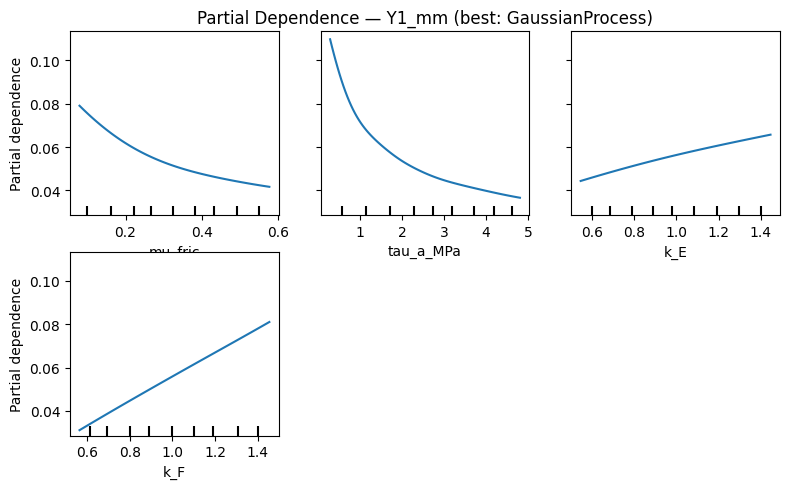

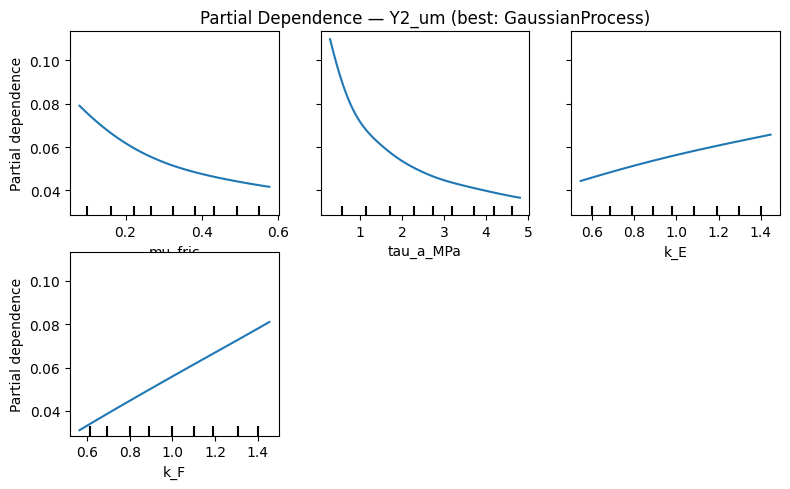

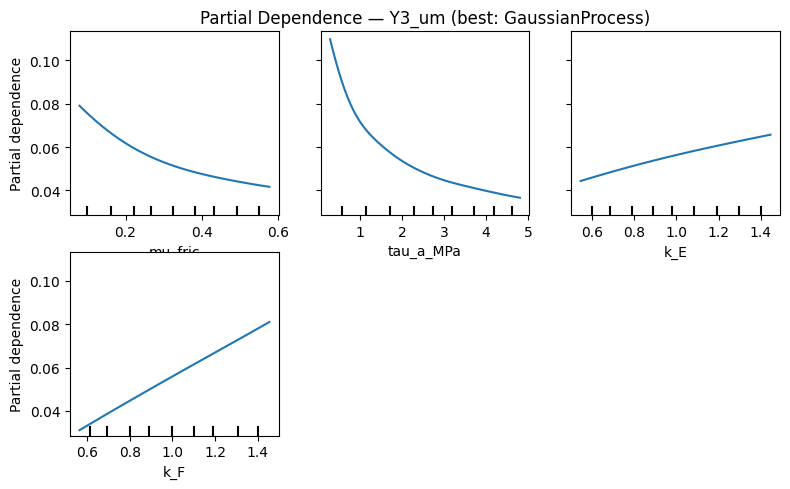

In [24]:
# ============================================================
# CELL 20 — Partial Dependence (1D) for each output
# ============================================================
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

best = res_df.sort_values(["target", "R2"], ascending=[True, False]).groupby("target").head(1)
best_map = {r["target"]: r["model"] for _, r in best.iterrows()}

for yname in TARGETS:
    est = fitted[(yname, best_map[yname])]

    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(
        est, Xtr, features=list(range(len(FEATURES))),
        feature_names=FEATURES,
        kind="average",
        ax=ax
    )
    ax.set_title(f"Partial Dependence — {yname} (best: {best_map[yname]})")
    plt.tight_layout()
    plt.show()


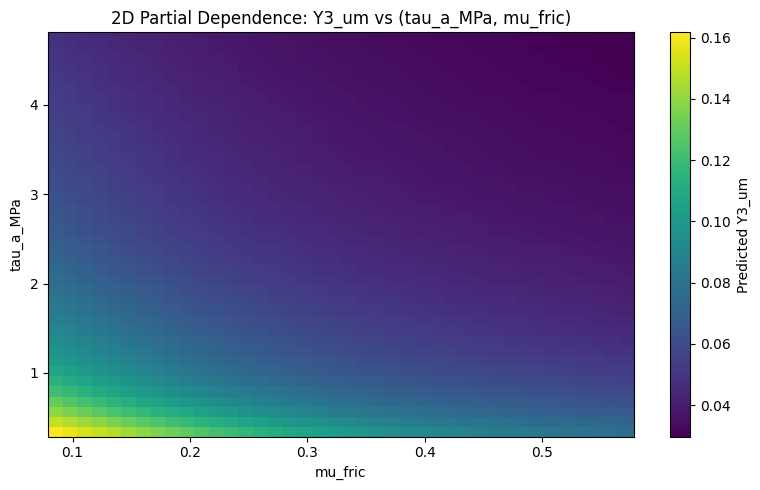

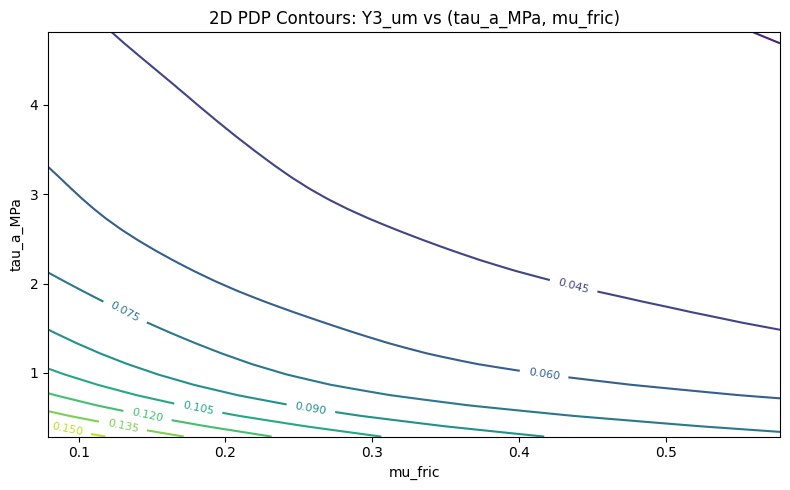

In [25]:
# ============================================================
# CELL 21 — 2D Partial Dependence: (tau_a_MPa, mu_fric) → Y3_um
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import partial_dependence

# best model for Y3 (from your earlier results)
est = fitted[("Y3_um", "GaussianProcess")]

# indices of features in FEATURES
i_tau = FEATURES.index("tau_a_MPa")
i_mu  = FEATURES.index("mu_fric")

pd = partial_dependence(
    est,
    X=Xtr,                           # use training distribution
    features=[(i_tau, i_mu)],
    grid_resolution=40               # increase to 60 if you want smoother
)

# Extract grid + surface
tau_grid = pd["grid_values"][0]      # for tau_a_MPa
mu_grid  = pd["grid_values"][1]      # for mu_fric
Z = pd["average"][0]                 # shape: (len(tau_grid), len(mu_grid))

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[mu_grid.min(), mu_grid.max(), tau_grid.min(), tau_grid.max()]
)
ax.set_xlabel("mu_fric")
ax.set_ylabel("tau_a_MPa")
ax.set_title("2D Partial Dependence: Y3_um vs (tau_a_MPa, mu_fric)")
plt.colorbar(im, ax=ax, label="Predicted Y3_um")
plt.tight_layout()
plt.show()

# Contours (often nicer for applications)
fig, ax = plt.subplots(figsize=(8, 5))
MU, TAU = np.meshgrid(mu_grid, tau_grid)
cs = ax.contour(MU, TAU, Z, levels=12)
ax.clabel(cs, inline=True, fontsize=8)
ax.set_xlabel("mu_fric")
ax.set_ylabel("tau_a_MPa")
ax.set_title("2D PDP Contours: Y3_um vs (tau_a_MPa, mu_fric)")
plt.tight_layout()
plt.show()


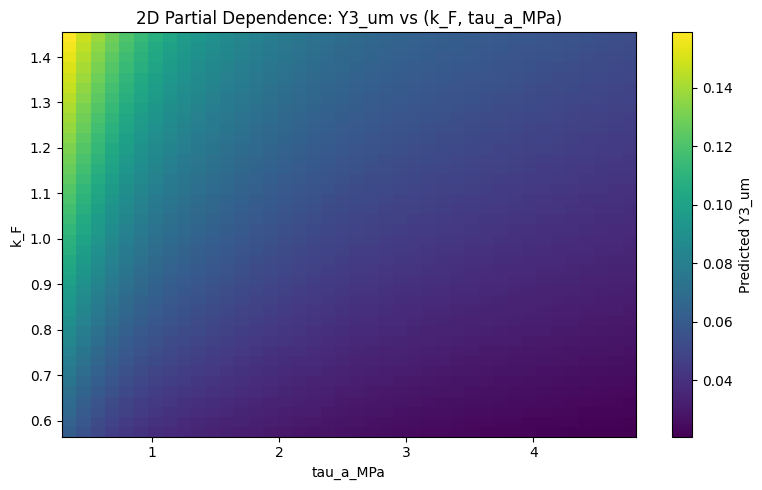

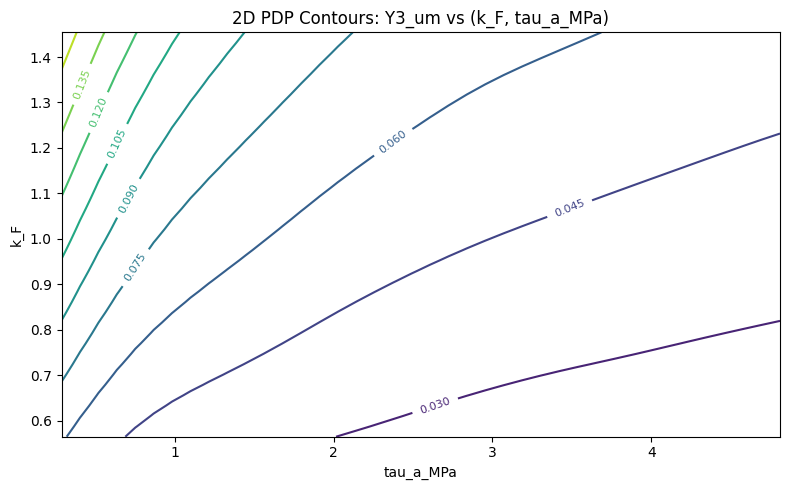

In [26]:
# ============================================================
# CELL 22 — 2D Partial Dependence: (k_F, tau_a_MPa) → Y3_um
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import partial_dependence

# Best surrogate for Y3
est = fitted[("Y3_um", "GaussianProcess")]

# Feature indices
i_kF  = FEATURES.index("k_F")
i_tau = FEATURES.index("tau_a_MPa")

pd = partial_dependence(
    est,
    X=Xtr,
    features=[(i_kF, i_tau)],
    grid_resolution=40
)

# Extract grids
kF_grid  = pd["grid_values"][0]
tau_grid = pd["grid_values"][1]
Z = pd["average"][0]   # shape: (len(kF_grid), len(tau_grid))

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[tau_grid.min(), tau_grid.max(), kF_grid.min(), kF_grid.max()]
)
ax.set_xlabel("tau_a_MPa")
ax.set_ylabel("k_F")
ax.set_title("2D Partial Dependence: Y3_um vs (k_F, tau_a_MPa)")
plt.colorbar(im, ax=ax, label="Predicted Y3_um")
plt.tight_layout()
plt.show()

# --- Contour plot ---
fig, ax = plt.subplots(figsize=(8, 5))
TAU, KF = np.meshgrid(tau_grid, kF_grid)
cs = ax.contour(TAU, KF, Z, levels=12)
ax.clabel(cs, inline=True, fontsize=8)
ax.set_xlabel("tau_a_MPa")
ax.set_ylabel("k_F")
ax.set_title("2D PDP Contours: Y3_um vs (k_F, tau_a_MPa)")
plt.tight_layout()
plt.show()
